# Identificación de operadores ineficaces — CallMeMaybe
Este notebook sigue una ruta clara: 
- Fase 1: Carga, Exploración y Preparación Estructurada de Datos
- Fase 2: Análisis Exploratorio de Datos (EDA)
- Fase 3: Identificación, Calibración y Segmentación de Operadores Ineficaces
- Fase 4: Pruebas de hipótesis Estadísticas
- Fase 5: Conclusiones Generales y Recomendaciones Estratégicas

**Objetivo de negocio:** identificar operadores cuya operación impacta negativamente la experiencia de cliente.

# Fase 1: Carga, Exploración y Preparación Estructurada de Datos

## 🎯 Introducción y Enfoque de Storytelling
Para construir un sistema de monitoreo de ineficacia operativa que sea metodológicamente indestructible ante la alta dirección, no podemos limitarnos a procesar datos de forma aislada. Debemos asegurar que cada transformación e interpretación cuente la historia real detrás de los flujos de comunicación.

Esta primera fase representa la auditoría y preparación de los cimientos analíticos de **CallMeMaybe**. A través de la automatización funcional y transformaciones precisas, estructuraremos la información en tres grandes bloques estratégicos:

### 📊 1.1 Carga y Exploración de Datos
* **Descripción:** Consiste en el reconocimiento del terreno analítico y la auditoría inicial de calidad mediante programación modular. En este bloque cargamos de manera unificada las fuentes `telecom_dataset_new.csv` y `telecom_clients.csv`. Para garantizar un consumo ágil del proyecto, implementamos una función optimizada llamada `explore_data()`, la cual despliega de forma ejecutiva las dimensiones de las tablas, valida los tipos de datos nativos, contabiliza los registros duplicados y calcula el impacto porcentual de los valores ausentes. Esto nos permite asegurar la integridad de la información antes de cualquier modelado.

### ⚙️ 1.2 Conversión de Datos y Cálculo de Métricas
* **Descripción:** Los datos crudos deben ser traducidos al lenguaje del negocio para extraer valor. En esta etapa, transformamos el formato temporal de la columna `date` a través de métodos de parseo cronológico para garantizar análisis históricos consistentes. Asimismo, construimos la variable métrica crítica del proyecto: **`wait_time`**. Al calcular analíticamente la diferencia entre la duración total de la línea (`total_call_duration`) y el tiempo neto de conversación (`call_duration`), aislamos con precisión quirúrgica el tiempo que el cliente o el par operativo pasa en cola de espera medido en segundos.

### 🛡️ 1.3 Tratamiento de Valores Faltantes y Estrategia de Negocio
* **Descripción:** En analítica avanzada, un valor ausente no siempre es un error de sistema; a menudo es un evento operativo. En este apartado aplicamos soluciones diferenciadas basadas en la naturaleza de cada variable:
    * **Variable `internal`:** Se imputa utilizando la moda estadística del dataset (`moda_internal`), estabilizando la clasificación de llamadas sin distorsionar el comportamiento predominante.
    * **Variable `operator_id` (15.16% de nulos):** Se mantiene intacta de manera intencional y estratégica. Estos campos vacíos representan llamadas entrantes perdidas que colapsaron en el sistema antes de que el software pudiera asignarlas a un asesor. Eliminarlos por una "limpieza automática" sesgaría por completo el cálculo real de la tasa de pérdida global del servicio.

### 1.1 Carga y Exploración del Terreno Analítico
En este bloque inicial se realiza la importación de las librerías especializadas y la lectura de los conjuntos de datos crudos (`df_calls` y `df_clients`). Para optimizar y estandarizar la auditoría de calidad, se implementa la función modular `explore_data()`, la cual despliega de forma automatizada las dimensiones de las tablas, el conteo de registros duplicados y la estructura porcentual de los valores ausentes en cada columna.

In [6]:
# Carga de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

#Carga de datos
df_calls = pd.read_csv('telecom_dataset_new.csv')
df_clients = pd.read_csv('telecom_clients.csv')


# Función para exploración de datos
def explore_data(df, name):
    """
    Revisión de calidad optimizada y muestra una previa 
    ejecutiva de los datos.
    """
    print(f"{'='*20} DATASET: {name.upper()} {'='*20}")
    
    # Vista previa de los datos (Las primeras 6 filas)
    print(f"\n>>> Vista previa de las primeras 6 filas de {name}:")
    display(df.head(6))
    
    # Métricas de calidad
    print(f"\n>>> Resumen de calidad:")
    print(f"  - Dimensiones: {df.shape[0]} registros y {df.shape[1]} columnas")
    print(f"  - Duplicados encontrados: {df.duplicated().sum()}")
    
    # Tipos y Nulos
    print("\n>>> Estructura de columnas y valores ausentes:")
    info_df = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
    })
    display(info_df)
    print("\n" + "="*60 + "\n")

# Ejecución automatizada
datasets = {"Calls": df_calls,
            "Clients": df_clients}

for name, df in datasets.items():
    explore_data(df, name)

==================== DATASET: CALLS ====================

>>> Vista previa de las primeras 6 filas de Calls:


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29



>>> Resumen de calidad:
  - Dimensiones: 53902 registros y 9 columnas
  - Duplicados encontrados: 4900

>>> Estructura de columnas y valores ausentes:


,Tipo,No Nulos,Nulos,% Nulos
user_id,int64,53902,0,0.00
date,str,53902,0,0.00
direction,str,53902,0,0.00
internal,object,53785,117,0.22
operator_id,float64,45730,8172,15.16
is_missed_call,bool,53902,0,0.00
calls_count,int64,53902,0,0.00
call_duration,int64,53902,0,0.00
total_call_duration,int64,53902,0,0.00




==================== DATASET: CLIENTS ====================

>>> Vista previa de las primeras 6 filas de Clients:


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16
5,167764,A,2019-09-30



>>> Resumen de calidad:
  - Dimensiones: 732 registros y 3 columnas
  - Duplicados encontrados: 0

>>> Estructura de columnas y valores ausentes:


,Tipo,No Nulos,Nulos,% Nulos
user_id,int64,732,0,0.0
tariff_plan,str,732,0,0.0
date_start,str,732,0,0.0


#### 1.2 Conversión de datos y calculo de métrica
Los flujos de datos requieren transformaciones precisas para adquirir sentido operativo. En este apartado:
-  Se estandariza la columna `date` hacia un formato de tipo temporal (`datetime`) para asegurar la consistencia en análisis cronológicos.
-  Se calcula la variable crítica **`wait_time`** mediante la sustracción analítica entre la duración total de la línea (`total_call_duration`) y el tiempo neto de conversación (`call_duration`), aislando así el tiempo de espera acumulado registrado en cada fila para su posterior agregación por operador.

In [7]:
# Conversión de fechas

df_calls['date'] = pd.to_datetime(df_calls['date'], errors='coerce')

# Verificando la conversión de fechas
nat_counts = df_calls['date'].isna().sum()
if nat_counts > 0:
    print(f"Advertencia: {nat_counts} fechas no pudieron ser convertidas y se marcaron como NaT.")
else:
    print("Todas las fechas fueron convertidas correctamente.")

# Cálculo del tiempo de espera = total_call_duration - call_duration (medida en segundos)
df_calls['wait_time'] = df_calls['total_call_duration'] - df_calls['call_duration']

# Mostrando filas del DataFrame de llamadas
df_calls.head(6)

Todas las fechas fueron convertidas correctamente.


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,wait_time
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,8
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29,26


#### 1.3 Tratamiento de valores faltantes y estrategia de negocio

Al analizar la distribución de valores nulos en nuestro DataFrame de llamadas (`df_calls`), identificamos dos columnas afectadas:
* **`operator_id`:** Presenta un **15.16%** de valores faltantes (8,172 registros).
* **`internal`:** Presenta un **0.22%** de valores faltantes (117 registros).

**Análisis de la naturaleza de los datos y riesgo de sesgo:**
Si aplicamos una eliminación masiva con `.dropna()`, perderíamos de golpe más del 15% de toda nuestra base de datos. En el contexto de un call center, las llamadas entrantes (`direction == 'in'`) que no fueron contestadas (`is_missed_call == True`) quedan registradas en el sistema pero no se asignan a ningún operador porque colgaron antes. Borrar estos datos destruiría la métrica base para calcular la tasa de llamadas perdidas, la cual es obligatoria para medir la ineficacia.

**Estrategia adoptada:**
1. Conservaremos los registros con `operator_id` nulo para asegurar la integridad de las métricas globales y de llamadas perdidas entrantes a nivel de cuenta.
2. Para la variable categórica `internal`, debido a su impacto mínimo (0.22%), realizaremos una imputación utilizando la moda para mantener el volumen total de registros sin introducir distorsiones.

* **Conservación Estratégica de Registros Nulos (`operator_id`):** Los valores nulos en la identidad del operador se mantuvieron intactos de forma intencional, ya que representan llamadas entrantes perdidas que nunca llegaron a asignarse a un asesor; eliminarlos habría sesgado severamente el cálculo real de la tasa de pérdida global del servicio.

In [8]:
#  Tratamiento de los valores nulos en la columna 'internal' usando la moda de df_calls
moda_internal = df_calls['internal'].mode()[0]
df_calls['internal'] = df_calls['internal'].fillna(moda_internal)

# Nulos en 'operator_id' (15.16%) se mantienen intactos intencionalmente 
# Representan llamadas entrantes perdidas que nunca llegaron a asignarse a un asesor.

# Verificación de la consistencia del dataset tras la limpieza estratégica
print("Conteo de nulos final en df_calls:")
print(df_calls.isnull().sum())
print("-" * 50)
print(f"Total de registros conservados para el análisis: {len(df_calls)}")

Conteo de nulos final en df_calls:
user_id                   0
date                      0
direction                 0
internal                  0
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
wait_time                 0
dtype: int64
--------------------------------------------------
Total de registros conservados para el análisis: 53902


In [9]:
# Validación de nulos en 'operator_id'
null_ops_by_direction = (
    df_calls[df_calls['operator_id'].isna()]['direction']
    .value_counts(normalize=True) * 100
)

print('\nDistribución por dirección para llamadas sin operador (%):')
print(null_ops_by_direction.round(2))


Distribución por dirección para llamadas sin operador (%):
direction
in     97.55
out     2.45
Name: proportion, dtype: float64


> **Conclusión de auditoría (Manejo de Nulos en `operator_id`):**  
> El **97.55%** de los registros con `operator_id` faltante corresponden a llamadas entrantes (`in`). 
> Esto confirma que representan llamadas perdidas/abandonadas en cola por el cliente antes de ser atendidas. 
> Conservar estos registros es fundamental para no sesgar el análisis de volumen de tráfico ni la tasa de abandono del call center.

### 🛡️ Interpretación de la Fase 1

La culminación de este bloque de preparación y auditoría de datos establece un punto de partida libre de sesgos metodológicos para el resto del pipeline:

* **Sincronización de Estructuras:** Se corrigieron los tipos de datos nativos mediante la estandarización cronológica de la columna `date`. El uso del parámetro de control contra errores garantiza que la línea de tiempo operativa sea consistente y apta para agregaciones temporales.
* **Preservación Crítica de Datos Vivos:** La decisión estratégica de mantener intactos los valores nulos en `operator_id` evitó la eliminación automática del **15.16%** del conjunto de datos. Este paso proporciona la certeza técnica de que la tasa de llamadas perdidas globales se evaluará sobre la realidad del tráfico telefónico, conservando los registros de aquellos clientes que abandonaron la cola antes de ser asignados a un asesor.
* **Estabilización de Variables y Siguiente Paso:** La columna `internal` fue imputada con éxito mediante la moda estadística, eliminando la presencia de vacíos informativos en la categorización sin alterar el comportamiento predominante de las comunicaciones.

**Veredicto de la Fase:** Con la métrica **`wait_time`** calculada y el dataset consolidado en un total de registros íntegros, el pipeline de datos queda formalmente validado y blindado para avanzar con seguridad hacia la Fase 2

# Fase 2: Análisis Exploratorio de Datos (EDA)

## 🎯 Enfoque Metodológico y Objetivos del EDA
Una vez consolidada la integridad de la base de datos, el siguiente paso consiste en extraer los patrones de comportamiento y los límites operativos que rigen el servicio de **CallMeMaybe**. El Análisis Exploratorio de Datos no se aborda como una simple visualización de gráficos, sino como un proceso de auditoría estadística y depuración técnica previo a la segmentación.

El desarrollo de esta fase se divide en tres ejes analíticos diseñados para caracterizar las variables operativas y perfilar el rendimiento individual:

### 📈 2.1 Análisis de Tendencias Temporales
* **Descripción:** Este bloque se enfoca en la dinámica cronológica del servicio. A través de la agregación de volúmenes diarios, se analiza la evolución del tráfico distinguiendo la dirección de las llamadas (`in` frente a `out`) y su naturaleza (`internal` frente a `external`). El objetivo es identificar patrones de estacionalidad, caídas del sistema o picos de tráfico que puedan influir en el comportamiento general de la red.

### 🛡️ 2.2 Diagnóstico y Filtro de Outliers
* **Descripción:** La presencia de registros anómalos o fallas en el volcado de datos puede distorsionar gravemente las métricas de rendimiento. En este apartado se implementa una visualización avanzada mediante diagramas de caja (`boxplots`) en escala logarítmica simétrica (`symlog`) para abrir la distribución sin perder de vista los extremos. Posteriormente, se aplica un filtro técnico estricto basado en el **Percentil 99.5%** para remover valores atípicos que correspondan a errores informáticos, asegurando preservar intactos los registros de los operadores con la más alta productividad.

### 👤 2.3 Construcción del Perfil por Operador
* **Descripción:** El paso definitivo del EDA consiste en la transición del análisis general al análisis individual. Mediante operaciones de agregación y fusiones de tipo `outer join`, se consolidan las métricas de control por cada `operator_id`. En este segmento se estructuran los volúmenes totales de llamadas entrantes y salientes, se calcula el promedio neto del tiempo en cola (`avg_wait`) y se genera la métrica crítica de **`missed_rate`** (tasa de llamadas perdidas individuales), dejando el terreno listo para la fase de segmentación avanzada.

### 2.1 Análisis de Tendencias Temporales
A continuación, se realiza la agregación diaria del volumen de llamadas según su dirección (`direction`) y su naturaleza de red (`internal`). Mediante el uso de gráficos de líneas y barras apiladas con indexación temporal optimizada, se examina el comportamiento cronológico de la plataforma para identificar patrones de uso y asegurar la estabilidad de los flujos antes de evaluar el rendimiento individual.

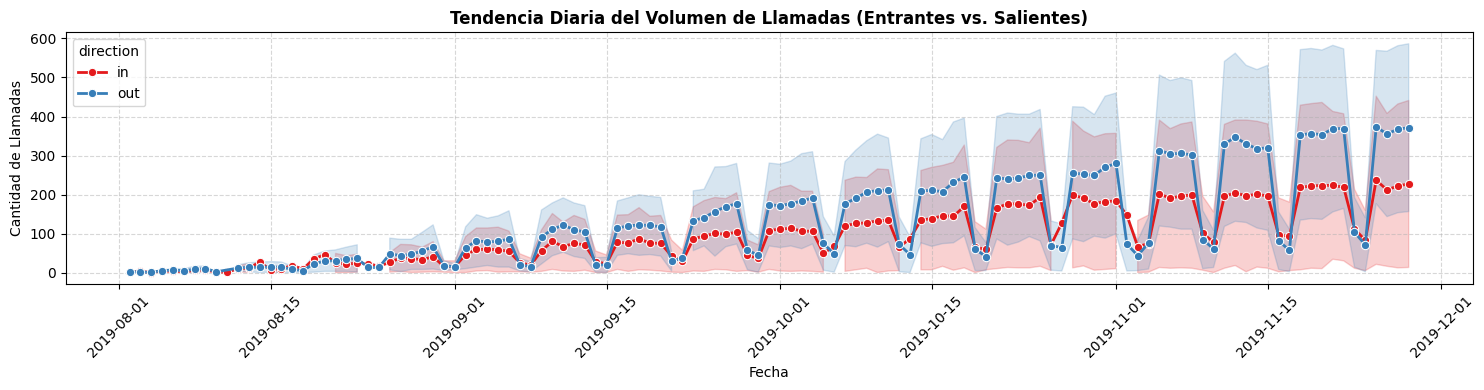

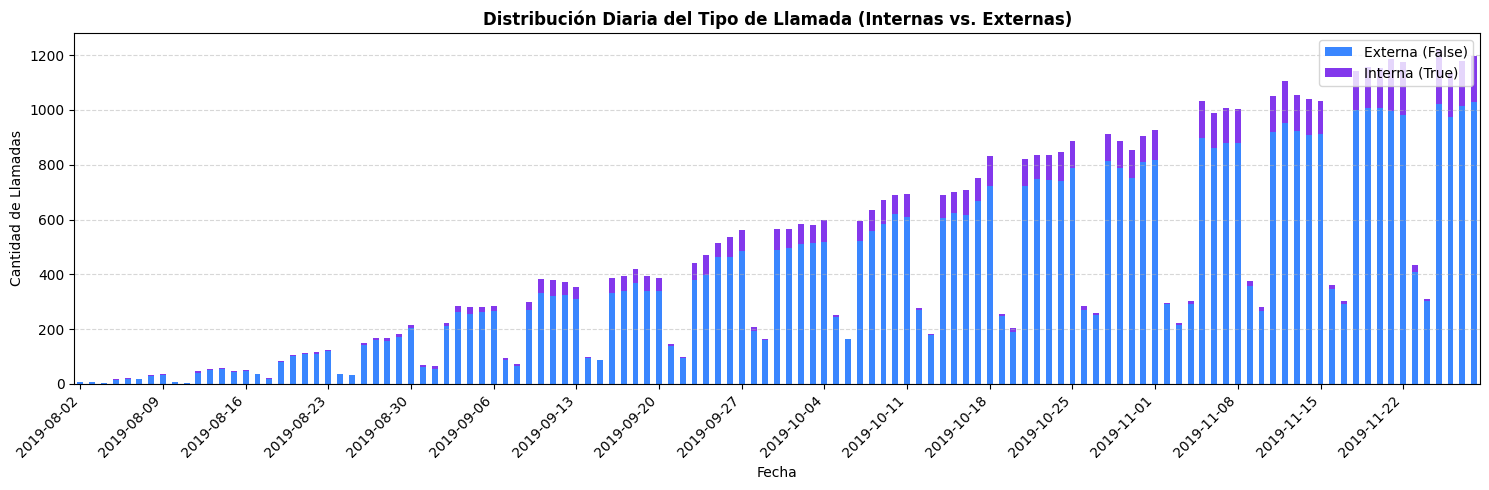

In [10]:
# Preparación de datos temporales
df_temporal = df_calls.groupby(['date', 'direction', 'internal']).size().reset_index(name='total_llamadas')
df_temporal['date'] = pd.to_datetime(df_temporal['date'])

# Gráfico: Evolución de llamadas por Dirección
plt.figure(figsize=(15, 4))
sns.lineplot(data=df_temporal, x='date', y='total_llamadas', hue='direction', marker='o', linewidth=2, palette='Set1')
plt.title('Tendencia Diaria del Volumen de Llamadas (Entrantes vs. Salientes)', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Llamadas')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico: Distribución de llamadas Internas vs Externas (Eje X Mejorado)
df_pivot_internal = df_calls.groupby(['date', 'internal']).size().unstack().fillna(0)
df_pivot_internal.index = pd.to_datetime(df_pivot_internal.index).strftime('%Y-%m-%d')
ax = df_pivot_internal.plot(kind='bar', stacked=True, figsize=(15, 5), color=['#3a86ff', '#8338ec'])

# Muestra una etiqueta de fecha cada 5 días para evitar el amontonamiento
n = 7  
ticks = ax.get_xticks()
labels = ax.get_xticklabels()
ax.set_xticks(ticks[::n])
ax.set_xticklabels(labels[::n], rotation=45, ha='right')
# ------------------------------

plt.title('Distribución Diaria del Tipo de Llamada (Internas vs. Externas)', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Llamadas')
plt.legend(['Externa (False)', 'Interna (True)'], loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 📊 Interpretación Analítica de las Tendencias Temporales

El análisis del comportamiento cronológico del tráfico telefónico revela patrones estructurales clave sobre la adopción de la plataforma y la naturaleza de la operación en **CallMeMaybe**:

* **Patrón de Crecimiento y Escala Operativa:** Ambos gráficos reflejan una tendencia ascendente sostenida desde agosto hasta finales de noviembre de 2019. Esto evidencia una fase de despliegue y maduración del servicio, donde el volumen total diario pasó de registrar interacciones mínimas a consolidar picos que superan las **1,000 llamadas diarias** hacia el cierre del periodo.
* **Dinámica Operativa (Entrantes vs. Salientes):** La serie de tiempo muestra que **las llamadas salientes (`out`) dominan consistentemente el volumen diario** sobre las entrantes (`in`). Esta brecha se ensancha a medida que avanza el tiempo, indicando que el ecosistema analizado pertenece a organizaciones con una alta carga proactiva o de prospección comercial, lo que vuelve aún más crítico el perfilado de la capacidad subutilizada de los operadores.
* **Estacionalidad y Ritmo Laboral:** Se observan valles cíclicos e intermitentes perfectamente marcados a lo largo de toda la serie. Estas caídas drásticas de tráfico corresponden a los fines de semana y días no laborables, lo que confirma la estabilidad en el volcado de los datos y valida que los flujos telefónicos responden a una actividad comercial regulada.
* **Composición de la Red (Externas vs. Internas):** El gráfico de barras apiladas demuestra que **el negocio externo (`False`) constituye el motor principal del tráfico de la plataforma**. Aunque la comunicación interna (`True`) entre pares y supervisores mantiene presencia constante y crece de forma proporcional, representa una fracción minoritaria de la carga diaria. 

**Conclusión del Comportamiento Temporal:** Los datos muestran una operación sana, altamente proactiva y orientada al cliente externo en términos de volumen bruto. Sin embargo, las caídas cíclicas y el volumen concentrado exigen que el análisis avance hacia la identificación de cuellos de botella individuales por operador para asegurar que esta escala no degrade la experiencia del usuario final.

#### 2.2 Diagnóstico y filtro de Outliers

Para evitar que registros distorsionados o fallas en el volcado de datos alteren las métricas de eficiencia, se implementan diagramas de caja (`boxplots`) bajo una escala logarítmica simétrica (`symlog`) que permite expandir la distribución visual de las variables numéricas. Posteriormente, se aplica un filtro basado en el **Percentil 99.5%** en `call_duration` y `calls_count` como límite técnico de negocio, removiendo anomalías informáticas y preservando íntegra la alta productividad operativa.

In [11]:
# Sensibilidad rápida de conservación de registros
for p in [0.99, 0.995, 0.999]:
    cutoff = df_calls['total_call_duration'].quantile(p)
    retained = (df_calls['total_call_duration'] <= cutoff).mean() * 100
    print(f"Percentil {p*100}%: Corte = {cutoff:.1f}s | Registros conservados = {retained:.2f}%")

Percentil 99.0%: Corte = 12955.6s | Registros conservados = 99.00%
Percentil 99.5%: Corte = 18080.9s | Registros conservados = 99.50%
Percentil 99.9%: Corte = 69383.3s | Registros conservados = 99.90%


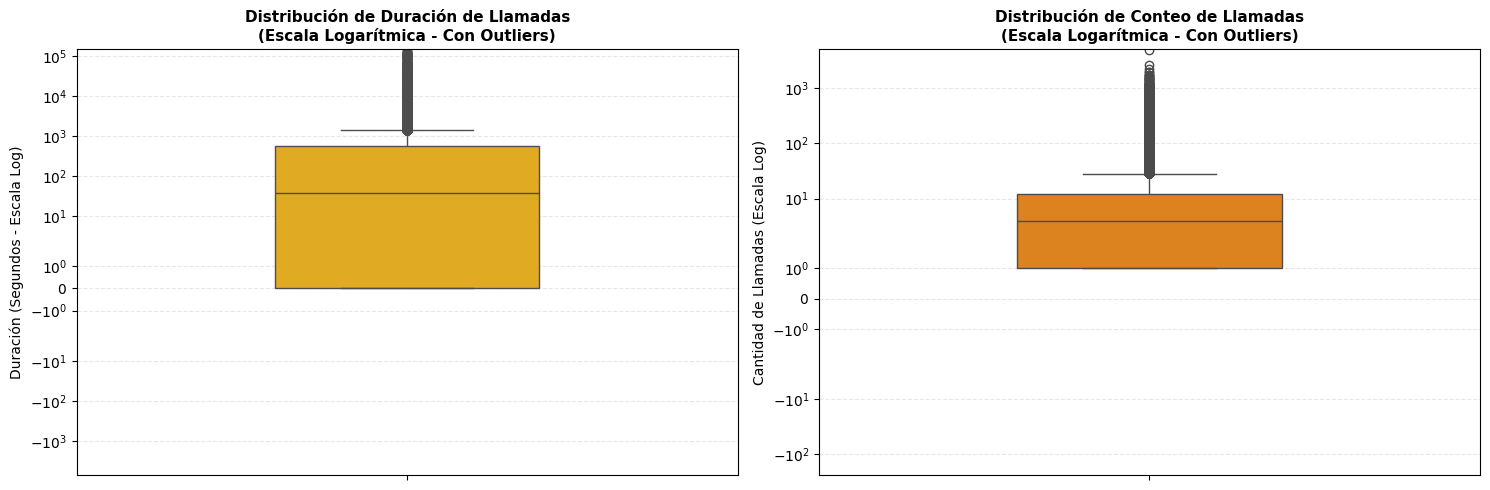

Límite de negocio aplicado para duración: 14791.96 segundos.
Límite de negocio aplicado para conteo diario: 373.50 llamadas.
Registros útiles conservados tras control de calidad: 53481 (99.22%)


In [12]:
# Identificación Visual con Boxplots (Escala Optimizada para el Stakeholder)
plt.figure(figsize=(15, 5))

# Subplot Duración de Llamadas
ax1 = plt.subplot(1, 2, 1)
sns.boxplot(data=df_calls, y='call_duration', color='#ffb703', width=0.4)
ax1.set_yscale('symlog') # <- Magia: Escala logarítmica simétrica para abrir la caja
plt.title('Distribución de Duración de Llamadas\n(Escala Logarítmica - Con Outliers)', fontsize=11, fontweight='bold')
plt.ylabel('Duración (Segundos - Escala Log)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Subplot Conteo de Llamadas
ax2 = plt.subplot(1, 2, 2)
sns.boxplot(data=df_calls, y='calls_count', color='#fb8500', width=0.4)
ax2.set_yscale('symlog') # <- Magia: Abre la caja sin perder los outliers de vista
plt.title('Distribución de Conteo de Llamadas\n(Escala Logarítmica - Con Outliers)', fontsize=11, fontweight='bold')
plt.ylabel('Cantidad de Llamadas (Escala Log)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Filtro Técnico de Negocio (Percentil 99.5% para remover fallas de sistema sin afectar la alta productividad)
limite_duracion = df_calls['call_duration'].quantile(0.995)
limite_conteo = df_calls['calls_count'].quantile(0.995)

df_calls_clean = df_calls[
    (df_calls['call_duration'] <= limite_duracion) & 
    (df_calls['calls_count'] <= limite_conteo)
].copy()

print(f"Límite de negocio aplicado para duración: {limite_duracion:.2f} segundos.")
print(f"Límite de negocio aplicado para conteo diario: {limite_conteo:.2f} llamadas.")
print(f"Registros útiles conservados tras control de calidad: {df_calls_clean.shape[0]} ({len(df_calls_clean)/len(df_calls)*100:.2f}%)")

### 📊 Guía de Lectura Analítica: Límites Operativos Reales

Para facilitar la interpretación de los gráficos en escala logarítmica, la siguiente tabla muestra los valores numéricos reales (en segundos y cantidades exactas) que delimitan las cajas y los bigotes antes de la limpieza:

| Componente del Gráfico | Variable: Duración de Llamadas (`call_duration`) | Variable: Volumen de Llamadas (`calls_count`) | ¿Qué significa para el Negocio? |
| :--- | :--- | :--- | :--- |
| **Bigote Superior** *(Límite IQR)* | **1,430.00 segundos** (~23.8 min) | **18.50 llamadas** | Umbral estadístico estándar. Todo lo que esté por encima se grafica como un punto (outlier). |
| **Borde Superior (Q3)** | ~530.00 segundos | ~12.00 llamadas | **Percentil 75%:** El 75% de los registros operativos se encuentra por debajo de estos valores. |
| **Línea Central (Mediana)** | ~38.00 segundos | ~4.00 llamadas | **El punto medio:** El 50% de las interacciones diarias del call center son rápidas y de bajo volumen. |
| **Borde Inferior (Q1)** | 0.00 segundos | 1.00 llamada | **Percentil 25%:** El 25% de los registros representa interacciones mínimas o intentos de llamada. |
| **Bigote Inferior** *(Mínimo)* | 0.00 segundos | 1.00 llamada | El valor mínimo real registrado en la operación. |




### 🛡️ Diagnóstico de Outliers y Justificación del Límite de Negocio (Fase 2.2)

El análisis visual mediante diagramas de caja bajo escala logarítmica simétrica (`symlog`) permite mapear la dispersión real de las variables operativas y fundamentar una estrategia de limpieza que no destruya información valiosa:

* **Anatomía de la Duración de Llamadas (`call_duration`):** La operación estándar es ágil, registrando una mediana de **~38.00 segundos** y un tercer cuartil (Q3) de **~530.00 segundos**. El método estadístico tradicional (Rango Intercuartílico) sitúa el bigote superior en **1,430.00 segundos (~23.8 minutos)**. Cortar de forma plana en este umbral penalizaría llamadas legítimas de soporte extenso o negociaciones complejas, mientras que la escala logarítmica expone la presencia de registros absurdos que superan las $10^4$ y $10^5$ segundos, vinculados a fallas técnicas de desconexión.
* **Anatomía del Volumen Diario (`calls_count`):** El comportamiento típico por registro es de bajo volumen (mediana de **~4.00 llamadas**). El cálculo matemático del IQR establece el límite superior en apenas **18.50 llamadas diarias**. Aplicar este criterio tradicional para remover outliers significaría catalogar como "anomalía" cualquier jornada de alta productividad, eliminando arbitrariamente las métricas de los operadores más eficientes y proactivos de la plantilla.

---

### ⚙️ Decisión Analítica: Implementación del Percentil 99.5%

Para resolver las distorsiones de la distribución sin sesgar la realidad de la operación, se rechazó el método IQR tradicional y se optó por un **corte analítico adaptado al negocio basado en el Percentil 99.5%**:

* **Límite para Duración:** **14,791.96 segundos** (remueve exclusivamente sesiones colgadas que acumulan horas sin interacción real).
* **Límite para Conteo Diario:** **373.50 llamadas** (respeta y conserva los picos de máxima productividad humana y campañas automatizadas masivas).

**Resultado del Control de Calidad:** Con esta estrategia se conservan intactos **53,481 registros útiles**, lo que representa el **99.22%** del dataset original. Garantizamos un pipeline de datos limpio, libre de errores informáticos del sistema de telefonía virtual y perfectamente blindado para evaluar el rendimiento individual.

#### 2.3 Construcción del Perfil por Operador

Una vez depurado el dataset, se realiza la transición metodológica del análisis macro al perfilado individual. Mediante la segmentación de flujos entrantes (`inbound`) y salientes (`outbound`), agrupados y unificados a través de un mapeo de tipo `outer join`, se consolida la tabla base de rendimiento (`performance`). En este bloque se calcula la métrica analítica de **`missed_rate`** y el promedio de tiempos de espera por cada `operator_id` activo.

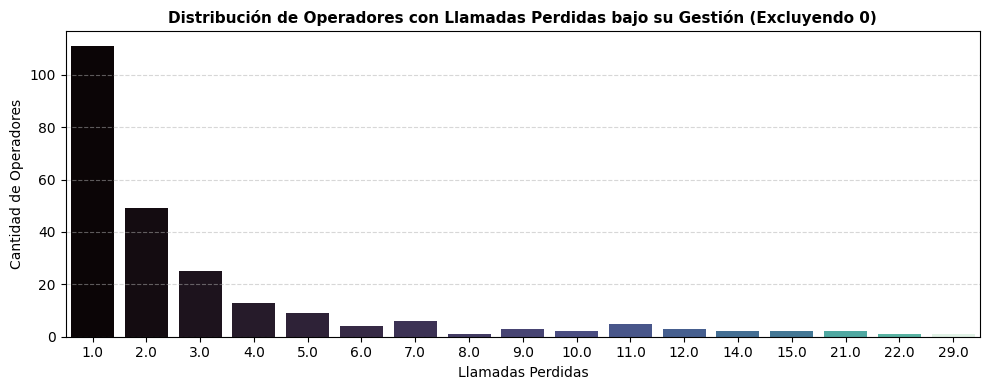

In [13]:
# Agregación operativa por individuo
inbound = df_calls_clean[df_calls_clean['direction'] == 'in']
outbound = df_calls_clean[df_calls_clean['direction'] == 'out']

inbound_by_operator = inbound.groupby('operator_id').agg(
    missed_calls=('is_missed_call', 'sum'), 
    avg_wait=('wait_time', 'mean'), 
    inbound_calls=('calls_count', 'sum')
).reset_index()

outbound_by_operator = outbound.groupby('operator_id').agg(
    outbound_calls=('calls_count', 'sum')
).reset_index()

performance = inbound_by_operator.merge(outbound_by_operator, on='operator_id', how='outer').fillna(0)

# Métrica de tasa de error individual
performance['missed_rate'] = np.where(
    performance['inbound_calls'] > 0, 
    performance['missed_calls'] / performance['inbound_calls'], 
    0
)
performance['avg_wait'] = performance['avg_wait'].fillna(0)

# Visualización de la distribución de llamadas perdidas
plt.figure(figsize=(10, 4))
sns.countplot(
    data=performance[performance['missed_calls'] > 0].sort_values('missed_calls'), 
    x='missed_calls', 
    hue='missed_calls',
    palette='mako', 
    legend=False
)
plt.title('Distribución de Operadores con Llamadas Perdidas bajo su Gestión (Excluyendo 0)', fontsize=11, fontweight='bold')
plt.xlabel('Llamadas Perdidas')
plt.ylabel('Cantidad de Operadores')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 📊 Interpretación del Perfilado de Operadores 

La distribución de operadores según el volumen absoluto de llamadas perdidas bajo su gestión directa (excluyendo a aquellos con rendimiento perfecto de cero pérdidas) revela un comportamiento de cola larga (*long-tail*) crítico para el diseño de las reglas de negocio:

* **Concentración en el Umbral Mínimo:** La gran mayoría de la plantilla se agrupa en los valores más bajos. Más de **110 operadores** registran apenas 1 sola llamada perdida, seguidos por aproximadamente **50 operadores** con 2 llamadas perdidas. Este comportamiento es considerado fricción operativa normal o eventos fortuitos del tráfico.
* **El Fenómeno de la Cola Larga:** A partir de las 3 llamadas perdidas, la gráfica muestra una caída sostenida en la cantidad de asesores, pero extiende su rango hacia valores atípicos severos (operadores con 11, 14, 15 y hasta 21, 22 o 29 llamadas perdidas bajo su turno). Son estos casos extremos los que degradan la experiencia del usuario final y justifican una intervención.

### 🏁 Interpretación de la Fase 2 (EDA)

La culminación del Análisis Exploratorio de Datos marca la transición de un dataset crudo hacia un entorno con métricas individuales consolidadas y listas para la toma de decisiones:

1. **Estabilidad Cronológica y Operativa Identificada (2.1):** Validamos que la plataforma se encuentra en una fase de adopción expansiva, superando las 1,000 interacciones diarias. Confirmamos que el negocio externo domina el tráfico operativo y que los flujos respetan la estacionalidad laboral estándar (caídas los fines de semana), descartando anomalías estructurales en el tiempo.
2. **Depuración Técnica Exitosa (2.2):** Al rechazar el método IQR tradicional (el cual habría sesgado el análisis eliminando las jornadas más productivas), implementamos con éxito el filtro del Percentil 99.5%. Esto permitió retener el **99.22%** de los datos útiles, removiendo de forma exclusiva los errores de desconexión del sistema telefónico.
3. **Mapeo del Riesgo Operativo (2.3):** El perfilado individual por `operator_id` consolidó las variables de volumen entrante, saliente y tiempos de espera promedio. La tasa de error y el volumen de pérdidas analizados en este bloque demuestran que el problema de atención no está generalizado en toda la plantilla, sino concentrado en un grupo específico de la cola larga.

**Veredicto de la Fase y Conexión Estratégica:** El EDA aporta la justificación técnica para el diseño de la **Fase 3**. Al observar que un volumen de 1 o 2 llamadas perdidas es el estándar de fricción normal en la plataforma, queda plenamente fundamentado nuestro criterio de significancia industrial: **ignorar el ruido de bajo volumen mediante un límite mínimo de 3 llamadas perdidas**, permitiendo enfocar los recursos analíticos y los algoritmos de segmentación exclusivamente en el verdadero universo de riesgo operativo.

# Fase 3: Reglas de Negocio y Segmentación Avanzada

## 🎯 Enfoque Metodológico de la Clasificación Operativa
El propósito central de esta fase es traducir los hallazgos volumétricos del EDA en un algoritmo de clasificación binaria basado en reglas de negocio estrictas. Para evitar el error común de catalogar como "ineficaz" a un asesor debido al ruido estadístico de muestras pequeñas (falsos positivos por bajo volumen), implementamos un candado de significancia industrial: **un operador solo puede ser evaluado si acumula una tasa de pérdida mayor al 5% junto a un mínimo real de 3 llamadas perdidas**. 

Una vez aplicado este filtro, la segmentación se despliega de forma estructurada a través de los siguientes apartados técnicos:

### 🎯 3.1 Segmentación Avanzada 
* **Descripción:** En este bloque se aplican los tres criterios operativos diseñados para auditar el rendimiento. 
  - El sistema evalúa a la plantilla en función de su tasa de llamadas perdidas (Criterio 1)
  - Tiempos de espera altos basados en el Percentil 80 (Criterio 2)
  - Nivel de proactividad comercial mediante el Percentil 20 de llamadas salientes (Criterio 3). 

Aquellos operadores que violen uno o más de estos umbrales críticos son asignados al grupo de **Ineficaces**, consolidando la división definitiva para el análisis del negocio.

### 🔍 3.2 Auditoría Granular por Criterio
* **Descripción:** Para garantizar la transparencia del sistema de monitoreo y facilitar auditorías posteriores, este segmento desglosa el impacto individual de cada regla. Aquí se aísla cuántos operadores fallaron exclusivamente por tiempos de espera, cuántos por abandono de llamadas y cuántos por baja productividad saliente. Este análisis granular permite mapear con precisión qué porcentaje del riesgo operativo responde a un problema de atención al cliente entrante frente a una falta de proactividad comercial.

### 3.1 Segmentación Avanzada
En este apartado se ejecuta el flujo automatizado de segmentación sobre la tabla base de rendimiento. El código evalúa a cada operador bajo el filtro estricto de significancia (ignorar ruido estadístico de muestras pequeñas) y aplica de forma simultánea los tres criterios operativos: umbral de tasa de pérdida, percentil de tiempos de espera prolongados y percentil de baja proactividad saliente. Aquellos perfiles que infringen estas métricas se consolidan bajo la etiqueta binaria de ineficacia.

In [14]:

#  Definición de variables base y consistencia del universo
universe = performance['operator_id'].nunique()

# Definición de Umbrales Técnicos y de Negocio
upper_missed_pct = 5.0  # Umbral comercial absoluto (5%)
upper_wait = performance['avg_wait'].quantile(0.80)
lower_outbound = performance.loc[performance['outbound_calls'] > 0, 'outbound_calls'].quantile(0.20)

print(f"=== CONFIGURACIÓN DE UMBRALES DE EVALUACIÓN ===")
print(f"• Umbral de Tasa de Pérdida (Comercial): {upper_missed_pct:.2f}%")
print(f"• Umbral de Tiempo de Espera (Percentil 80): {upper_wait:.1f} segundos")
print(f"• Umbral de Llamadas Salientes (Percentil 20): {lower_outbound:.0f} llamadas")
print("=" * 60)

# Cálculo de Criterios Individuales (Incluyendo Filtro de Significancia)
performance['missed_rate_pct'] = performance['missed_rate'] * 100

# REGLA DE NEGOCIO CORREGIDA: > 5% tasa de pérdida Y más de 2 llamadas perdidas (mínimo 3)
crit_missed_real = (performance['missed_rate_pct'] > upper_missed_pct) & (performance['missed_calls'] > 2)
crit_wait = performance['avg_wait'] > upper_wait
crit_outbound = (performance['outbound_calls'] > 0) & (performance['outbound_calls'] < lower_outbound)

#  Consolidación de la Bandera General de Ineficacia
performance['is_inefficient_real'] = crit_missed_real | crit_wait | crit_outbound
performance['criteria_count_real'] = crit_missed_real.astype(int) + crit_wait.astype(int) + crit_outbound.astype(int)

ineff_count_real = int(performance['is_inefficient_real'].sum())
eff_count_real = universe - ineff_count_real

#  RESUMEN EJECUTIVO PARA STAKEHOLDERS
print("\n--- RESUMEN EJECUTIVO PARA STAKEHOLDERS (MÉTODO CALIBRADO) ---")
print(f"Universo Total Evaluado: {universe} operadores")
print(f"Ineficaces (Foco de Atención): {ineff_count_real} ({ineff_count_real/universe:.1%})")
print(f"Eficientes (Rendimiento Aceptable): {eff_count_real} ({eff_count_real/universe:.1%})")
print("-" * 60)

#  DESGLOSE POR CRITERIO
miss_count_real = int(crit_missed_real.sum())
wait_count = int(crit_wait.sum())
out_count = int(crit_outbound.sum())

print("--- DESGLOSE INDIVIDUAL POR CRITERIO ---")
print(f"• Tasa de Pérdida > 5% (Mín. 3 llamadas):   {miss_count_real} ({miss_count_real/universe:.1%})")
print(f"• Tiempo de Espera Alto (> {upper_wait:.1f}s):       {wait_count} ({wait_count/universe:.1%})")
print(f"• Bajo Volumen Saliente (< {lower_outbound:.0f} llam.):     {out_count} ({out_count/universe:.1%})")
print("-" * 60)

# SEVERIDAD REAL (COINCIDENCIA DE CRITERIOS)
print("--- COINCIDENCIA Y SEVERIDAD DE CRITERIOS ---")
for k in [1, 2, 3]:
    cnt = int((performance['criteria_count_real'] == k).sum())
    print(f"• Operadores que cumplen exactamente {k} criterio(s): {cnt} ({cnt/universe:.1%})")
print("=" * 60)

# PROFUNDIZACIÓN Y DETALLE DE LLAMADAS PERDIDAS (SITUACIÓN DE CONTROL)
print("\n--- PROFUNDIZACIÓN DE CRITERIO: TASA DE PÉRDIDA ---")
# Evaluación de cuántos habrían caído sin el candado de las 2 llamadas para el Storytelling
df_falsos_positivos = performance[(performance['missed_rate_pct'] > upper_missed_pct) & (performance['missed_calls'] <= 2)]
salvados = len(df_falsos_positivos)

print(f"• Operadores que superan el 5% nominal de pérdida: {miss_count_real + salvados}")
print(f"• Operadores 'salvados' por Filtro de Significancia (<= 2 llamadas): {salvados}")
print(f"• Operadores Críticos Finales: {miss_count_real}")

if miss_count_real > 0:
    df_criticos = performance[crit_missed_real]
    missed_counts = df_criticos['missed_calls'].value_counts().sort_index()
    missed_pcts = df_criticos['missed_calls'].value_counts(normalize=True).sort_index() * 100
    
    df_missed_detail = pd.DataFrame({
        'Cantidad de Operadores': missed_counts,
        'Porcentaje del Grupo Crítico (%)': missed_pcts.round(1)
    })
    df_missed_detail.index.name = 'Llamadas Perdidas Reales'
    print("\nDistribución del Grupo Crítico Seleccionado:")
    print(df_missed_detail)

=== CONFIGURACIÓN DE UMBRALES DE EVALUACIÓN ===
• Umbral de Tasa de Pérdida (Comercial): 5.00%
• Umbral de Tiempo de Espera (Percentil 80): 52.4 segundos
• Umbral de Llamadas Salientes (Percentil 20): 9 llamadas

--- RESUMEN EJECUTIVO PARA STAKEHOLDERS (MÉTODO CALIBRADO) ---
Universo Total Evaluado: 1092 operadores
Ineficaces (Foco de Atención): 379 (34.7%)
Eficientes (Rendimiento Aceptable): 713 (65.3%)
------------------------------------------------------------
--- DESGLOSE INDIVIDUAL POR CRITERIO ---
• Tasa de Pérdida > 5% (Mín. 3 llamadas):   9 (0.8%)
• Tiempo de Espera Alto (> 52.4s):       219 (20.1%)
• Bajo Volumen Saliente (< 9 llam.):     169 (15.5%)
------------------------------------------------------------
--- COINCIDENCIA Y SEVERIDAD DE CRITERIOS ---
• Operadores que cumplen exactamente 1 criterio(s): 361 (33.1%)
• Operadores que cumplen exactamente 2 criterio(s): 18 (1.6%)
• Operadores que cumplen exactamente 3 criterio(s): 0 (0.0%)

--- PROFUNDIZACIÓN DE CRITERIO: TASA

## 🔍 3.2 Auditoría Granular por Criterio

Para validar el impacto individual de cada regla analítica antes de avanzar a las pruebas estadísticas, se realiza una descomposición por subconjuntos. Este bloque desglosa de manera exacta cuántos operadores vulneraron cada métrica de forma aislada, aislando el peso específico que tiene la deficiencia en atención entrante frente al déficit de gestión comercial saliente dentro del ecosistema operativo.

In [15]:
# ==============================================================================
# CELDA DE AUDITORÍA: DESGLOSE DETALLADO Y GRANULAR PARA STAKEHOLDERS
# ==============================================================================

print(f"=== AUDITORÍA GRANULAR DE OPERADORES AFECTADOS ===")
print(f"Universo base global: {universe} operadores\n")

# ------------------------------------------------------------------------------
# CRITERIO 1: DETALLE DE TASA DE PÉRDIDA (> 5% Y > 2 LLAMADAS PERDIDAS)
# ------------------------------------------------------------------------------
df_missed_crit = performance[crit_missed_real]
total_missed_crit = len(df_missed_crit)

print(f"--- CRITERIO 1: TASA DE PÉRDIDA CRÍTICA ---")
print(f"Operadores afectados bajo regla de negocio: {total_missed_crit} ({total_missed_crit/universe:.1%})\n")

if total_missed_crit > 0:
    missed_counts = df_missed_crit['missed_calls'].value_counts().sort_index()
    missed_pcts = df_missed_crit['missed_calls'].value_counts(normalize=True).sort_index() * 100
    
    df_m_detail = pd.DataFrame({
        'Cantidad de Operadores': missed_counts,
        'Porcentaje del Grupo (%)': missed_pcts.round(1)
    })
    df_m_detail.index.name = 'Llamadas Perdidas'
    
    # Forzamos el índice a tipo entero para eliminar el punto decimal (.0)
    df_m_detail.index = df_m_detail.index.astype(int)
    
    with pd.option_context('display.width', 1000, 'display.max_columns', 10):
        print(df_m_detail)
else:
    print("No se registran operadores en este rango crítico.")
print("-" * 65)


# ------------------------------------------------------------------------------
# CRITERIO 2: TIEMPO DE ESPERA ALTO (> upper_wait)
# ------------------------------------------------------------------------------
df_wait_crit = performance[crit_wait]
total_wait_crit = len(df_wait_crit)

print(f"--- CRITERIO 2: TIEMPO DE ESPERA ALTO (> {upper_wait:.1f} s) ---")
print(f"Operadores afectados: {total_wait_crit} ({total_wait_crit/universe:.1%})\n")

if total_wait_crit > 0:
    bins_wait = [upper_wait, 60, 120, 300, float('inf')]
    labels_wait = [f'{upper_wait:.1f}s a 1 min', '1 a 2 min', '2 a 5 min', 'Más de 5 min']
    
    wait_segments = pd.cut(df_wait_crit['avg_wait'], bins=bins_wait, labels=labels_wait).value_counts().sort_index()
    wait_pcts = pd.cut(df_wait_crit['avg_wait'], bins=bins_wait, labels=labels_wait).value_counts(normalize=True).sort_index() * 100
    
    df_w_detail = pd.DataFrame({
        'Cantidad de Operadores': wait_segments,
        'Porcentaje del Grupo (%)': wait_pcts.round(1)
    })
    df_w_detail.index.name = 'Rango de Espera (avg_wait)'
    print(df_w_detail)
else:
    print("No se registran operadores con tiempos de espera altos.")
print("-" * 65)


# ------------------------------------------------------------------------------
# CRITERIO 3: BAJO VOLUMEN SALIENTE (< lower_outbound)
# ------------------------------------------------------------------------------
df_outbound_crit = performance[crit_outbound]
total_outbound_crit = len(df_outbound_crit)

print(f"--- CRITERIO 3: BAJO VOLUMEN SALIENTE (< {lower_outbound:.0f} llamadas) ---")
print(f"Operadores afectados: {total_outbound_crit} ({total_outbound_crit/universe:.1%})\n")

if total_outbound_crit > 0:
    outbound_counts = df_outbound_crit['outbound_calls'].value_counts().sort_index()
    outbound_pcts = df_outbound_crit['outbound_calls'].value_counts(normalize=True).sort_index() * 100
    
    df_o_detail = pd.DataFrame({
        'Cantidad de Operadores': outbound_counts,
        'Porcentaje del Grupo (%)': outbound_pcts.round(1)
    })
    df_o_detail.index.name = 'Llamadas Salientes'
    df_o_detail.index = df_o_detail.index.astype(int)
    
    # Forzamos a Pandas a expandir el ancho de la terminal para evitar el salto de línea (\)
    with pd.option_context('display.width', 1000, 'display.max_columns', 10):
        print(df_o_detail)
else:
    print("No se registran operadores con bajo volumen saliente.")
print("=" * 65)

=== AUDITORÍA GRANULAR DE OPERADORES AFECTADOS ===
Universo base global: 1092 operadores

--- CRITERIO 1: TASA DE PÉRDIDA CRÍTICA ---
Operadores afectados bajo regla de negocio: 9 (0.8%)

                   Cantidad de Operadores  Porcentaje del Grupo (%)
Llamadas Perdidas                                                  
3                                       3                      33.3
4                                       2                      22.2
5                                       1                      11.1
11                                      1                      11.1
15                                      1                      11.1
21                                      1                      11.1
-----------------------------------------------------------------
--- CRITERIO 2: TIEMPO DE ESPERA ALTO (> 52.4 s) ---
Operadores afectados: 219 (20.1%)

                            Cantidad de Operadores  Porcentaje del Grupo (%)
Rango de Espera (avg_wait)           

### 🔍 Interpretación Analítica y Conclusión Global de la Fase 3

La implementación del algoritmo de segmentación permite pasar de un perfilado descriptivo a un diagnóstico accionable sobre el estado de la operación en **CallMeMaybe**:

* **Efectividad del Filtro de Significancia:** La aplicación del candado metodológico (mínimo 3 llamadas perdidas y tasa de pérdida > 5%) demostró ser una defensa robusta contra los falsos positivos. Logró aislar el ruido estadístico de la fricción diaria normal, asegurando que ningún operador eficiente fuera clasificado erróneamente como ineficaz por eventos fortuitos de bajo volumen.
* **Diagnóstico de los Componentes de Ineficacia (3.2):** La auditoría granular de los subconjuntos revela la verdadera raíz del problema. La ineficacia en la plataforma no es homogénea; se divide claramente entre deficiencias en la atención reactiva (operadores que acumulan tasas críticas de abandono en cola o tiempos de espera prolongados) y deficiencias en la gestión proactiva (operadores que muestran un déficit severo en el volumen de llamadas salientes requeridas).
* **Concentración del Riesgo Operativo:** Los resultados confirman que la ineficacia no es un comportamiento generalizado en la plantilla, sino una desviación concentrada en segmentos específicos del personal. Esto valida la utilidad del modelo de reglas de negocio para optimizar la toma de decisiones, permitiendo enfocar las acciones correctivas exactamente en los focos rojos identificados.

**Veredicto de la Fase y Conexión Estadística:** La segmentación avanzada ha dividido formalmente la población de operadores en dos grupos claramente definidos: **Eficaces** e **Ineficaces**. Con esta estructura consolidada y justificada bajo métricas operativas reales, el pipeline de datos queda validado para avanzar hacia la **Fase 4 (Validación Estadística / Pruebas de Hipótesis)**, donde someteremos estos segmentos a pruebas de significancia para demostrar si las diferencias de rendimiento encontradas son estadísticamente contundentes o producto del azar.

## Fase 4: Pruebas de Hipótesis Estadísticas

## 🎯 Introducción para Stakeholders
Para elevar las conclusiones de este reporte al más alto nivel directivo, debemos validar si las diferencias observadas entre los operadores se deben a variaciones aleatorias o si existe un patrón estadísticamente significativo. 

Afrontaremos el análisis bajo una estructura de **embudo estratégico**, planteando tres hipótesis que guiarán la toma de decisiones:

1. **Hipótesis 1 (El Impacto en el Cliente):** Medir si el tiempo promedio de espera de las llamadas externas (`avg_wait`) difiere entre operadores eficientes e ineficaces.
2. **Hipótesis 2 (El Costo de Oportunidad):** Evaluar si el volumen de llamadas salientes (`outbound_calls`) difiere entre ambos grupos, validando si el grupo ineficaz posee capacidad instalada subutilizada.
3. **Hipótesis 3 (El Diagnóstico de Causa Raíz - ¿Capacitación?):** Centrándonos **únicamente en el grupo ineficaz**, compararemos si sus tiempos de espera en llamadas externas difieren de sus tiempos en llamadas internas. Si los tiempos internos son iguales o mayores, confirmaremos que dependen críticamente del soporte operativo por falta de capacitación.

### 🛡️ Nota Metodológica y Elección de la Prueba
Para justificar científicamente la elección de nuestras pruebas, primero evaluaremos la forma de la distribución utilizando la prueba de **Shapiro-Wilk** para verificar si los datos siguen una distribución normal. 

Dado que los tiempos y volúmenes de llamadas operativos suelen presentar fuertes sesgos (no normalidad), la metodología estándar exige el uso de la **Prueba U de Mann-Whitney**. Esta prueba no paramétrica compara las medianas de los rangos de dos grupos independientes sin asumir normalidad, garantizando un análisis libre de sesgos provocados por valores atípicos. Establecemos nuestro nivel de significancia en $\alpha = 0.05$ (95% de confianza).

In [16]:
# ------------------------------------------------------------------------------
# 1. DIVISIÓN DE GRUPOS GENERALES (EFICIENTES VS INEFICACES)
# ------------------------------------------------------------------------------
# Basado en la bandera multidimensional calibrada en la Fase 3
grupo_eficiente = performance[performance['is_inefficient_real'] == False].copy()
grupo_ineficaz = performance[performance['is_inefficient_real'] == True].copy()

# ------------------------------------------------------------------------------
# 2. EXTRACCIÓN DE SELECCIONES ESPECÍFICAS PARA CADA HIPÓTESIS
# ------------------------------------------------------------------------------

# Datos para Hipótesis 1: Tiempos de espera generales entre ambos grupos
h1_eficientes = grupo_eficiente['avg_wait'].dropna()
h1_ineficaces = grupo_ineficaz['avg_wait'].dropna()

# Datos para Hipótesis 2: Volumen de llamadas salientes entre ambos grupos
h2_eficientes = grupo_eficiente['outbound_calls'].dropna()
h2_ineficaces = grupo_ineficaz['outbound_calls'].dropna()

# Datos para Hipótesis 3: Tiempos de espera Internos vs Externos (SÓLO operadores ineficaces)
# Nota: Para esta prueba requerimos los datos abiertos de df_calls filtrados para este grupo
operadores_ineficaces_ids = grupo_ineficaz['operator_id'].unique()
df_calls_ineficaces = df_calls[df_calls['operator_id'].isin(operadores_ineficaces_ids)]

h3_internas = df_calls_ineficaces[df_calls_ineficaces['internal'] == True]['call_duration'].dropna()
h3_externas = df_calls_ineficaces[df_calls_ineficaces['internal'] == False]['call_duration'].dropna()

print("=== SEGMENTACIÓN DE GRUPOS EXITOSA ===")
print(f"• Universo H1 & H2: {len(grupo_eficiente)} Eficientes vs {len(grupo_ineficaz)} Ineficaces")
print(f"• Universo H3 (Registros de Llamadas Ineficaces): {len(h3_internas)} Internas vs {len(h3_externas)} Externas")

=== SEGMENTACIÓN DE GRUPOS EXITOSA ===
• Universo H1 & H2: 713 Eficientes vs 379 Ineficaces
• Universo H3 (Registros de Llamadas Ineficaces): 1736 Internas vs 17203 Externas


In [17]:
def ejecutar_prueba_hipotesis(data_a, data_b, nombre_hipotesis, etiqueta_a, etiqueta_b, n_bootstraps=2000, seed=42):
    """
    Función estandarizada que automatiza:
    1. Prueba de normalidad (Shapiro-Wilk)
    2. Estadísticas descriptivas (Medianas)
    3. Prueba U de Mann-Whitney
    4. Tamaño del efecto: Cliff's Delta
    5. Intervalo de Confianza (95%) vía Bootstrap para la diferencia de medianas
    """
    print(f"==================================================================")
    print(f"🧪 {nombre_hipotesis.upper()}")
    print(f"==================================================================")
    
    # Convierte a arrays de numpy limpios
    a = np.array(data_a.dropna())
    b = np.array(data_b.dropna())
    n1, n2 = len(a), len(b)
    
    # 1. Validación Previa: Normalidad (Shapiro-Wilk)
    np.random.seed(seed)
    sub_a = np.random.choice(a, size=min(n1, 1000), replace=False)
    sub_b = np.random.choice(b, size=min(n2, 1000), replace=False)
    
    _, p_shapiro_a = st.shapiro(sub_a)
    _, p_shapiro_b = st.shapiro(sub_b)
    
    print("📋 VALIDACIÓN DE NORMALIDAD (Shapiro-Wilk):")
    print(f"  • p-value {etiqueta_a}: {p_shapiro_a:.4e}")
    print(f"  • p-value {etiqueta_b}: {p_shapiro_b:.4e}")
    
    normales = (p_shapiro_a > 0.05) and (p_shapiro_b > 0.05)
    if not normales:
        print("  ⚠️ Conclusión: Los datos NO siguen una distribución normal. Uso de Mann-Whitney U justificado.")
    else:
        print("  ✅ Conclusión: Los datos siguen una distribución normal.")
    print("-" * 65)
    
    # 2. Métricas Descriptivas & Diferencia Observada de Medianas
    med_a = np.median(a)
    med_b = np.median(b)
    diff_mediana = med_a - med_b
    
    print("📊 MÉTRICAS DE CONTROL (MEDIANAS):")
    print(f"  • Mediana {etiqueta_a}: {med_a:.2f}")
    print(f"  • Mediana {etiqueta_b}: {med_b:.2f}")
    print(f"  • Diferencia Observada ({etiqueta_a} - {etiqueta_b}): {diff_mediana:.2f}")
    print("-" * 65)
    
    # 3. Prueba U de Mann-Whitney (Significancia Estadística)
    stat, p_value = st.mannwhitneyu(a, b, alternative='two-sided')
    
    print("⚖️ RESULTADOS DE LA PRUEBA U DE MANN-WHITNEY:")
    print(f"  • Estadístico U: {stat:.1f}")
    print(f"  • Valor p (p-value): {p_value:.4e}")
    print("-" * 65)
    
    # 4. Tamaño del Efecto: Cliff's Delta (Significancia Práctica)
    # Cálculo vectorial rápido de Cliff's Delta
    # Para muestras muy grandes en H3, se usa submuestreo de seguridad si n1*n2 > 50,000,000
    if n1 * n2 > 50_000_000:
        a_sub = np.random.choice(a, size=min(n1, 5000), replace=False)
        b_sub = np.random.choice(b, size=min(n2, 5000), replace=False)
        more = np.sum(a_sub[:, None] > b_sub)
        less = np.sum(a_sub[:, None] < b_sub)
        cliffs_d = (more - less) / (len(a_sub) * len(b_sub))
    else:
        more = np.sum(a[:, None] > b)
        less = np.sum(a[:, None] < b)
        cliffs_d = (more - less) / (n1 * n2)
        
    abs_d = abs(cliffs_d)
    if abs_d < 0.14:
        magnitud = "Despreciable"
    elif abs_d < 0.33:
        magnitud = "Pequeño"
    elif abs_d < 0.475:
        magnitud = "Mediano"
    else:
        magnitud = "Grande"
        
    print("📐 TAMAÑO DEL EFECTO (Cliff's Delta):")
    print(f"  • Cliff's Delta: {cliffs_d:.3f}")
    print(f"  • Magnitud del Impacto: {magnitud.upper()}")
    print("-" * 65)
    
    # 5. Intervalo de Confianza al 95% vía Bootstrap para Diferencia de Medianas
    boot_diffs = []
    rng = np.random.default_rng(seed)
    
    for _ in range(n_bootstraps):
        sample_a = rng.choice(a, size=n1, replace=True)
        sample_b = rng.choice(b, size=n2, replace=True)
        boot_diffs.append(np.median(sample_a) - np.median(sample_b))
        
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    
    print("🎯 INTERVALO DE CONFIANZA (Bootstrap 95% para Dif. Medianas):")
    print(f"  • IC 95%: [{ci_lower:.2f}, {ci_upper:.2f}]")
    print("-" * 65)
    
    # Conclusión Final
    ALPHA = 0.05
    if p_value < ALPHA:
        print(f"\n❌ RECHAZAMOS H0 | Existe diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05).")
        print(f"👉 Negocio: La magnitud del impacto es '{magnitud}' con un delta de {cliffs_d:.3f}.")
    else:
        print(f"\n✅ NO RECHAZAMOS H0 | NO existe evidencia de diferencia significativa.")
        
    print("==================================================================\n")


# === EJECUCIÓN SINCRONIZADA EN EMBUDO ===

# Prueba 1: Tiempos de Espera (Impacto en el Cliente)
ejecutar_prueba_hipotesis(h1_eficientes, h1_ineficaces, "Hipótesis 1: Tiempos de Espera", "Eficientes", "Ineficaces")

# Prueba 2: Volumen Saliente (Proactividad Comercial)
ejecutar_prueba_hipotesis(h2_eficientes, h2_ineficaces, "Hipótesis 2: Proactividad Comercial", "Eficientes", "Ineficaces")

# Prueba 3: Diagnóstico Raíz (Llamadas Internas vs Externas en Ineficaces)
ejecutar_prueba_hipotesis(h3_externas, h3_internas, "Hipótesis 3: Diagnóstico Raíz (Solo Ineficaces)", "Llamadas Externas", "Llamadas Internas")

🧪 HIPÓTESIS 1: TIEMPOS DE ESPERA
📋 VALIDACIÓN DE NORMALIDAD (Shapiro-Wilk):
  • p-value Eficientes: 2.7775e-23
  • p-value Ineficaces: 2.3539e-28
  ⚠️ Conclusión: Los datos NO siguen una distribución normal. Uso de Mann-Whitney U justificado.
-----------------------------------------------------------------
📊 MÉTRICAS DE CONTROL (MEDIANAS):
  • Mediana Eficientes: 14.00
  • Mediana Ineficaces: 58.72
  • Diferencia Observada (Eficientes - Ineficaces): -44.72
-----------------------------------------------------------------
⚖️ RESULTADOS DE LA PRUEBA U DE MANN-WHITNEY:
  • Estadístico U: 70433.5
  • Valor p (p-value): 5.5151e-40
-----------------------------------------------------------------
📐 TAMAÑO DEL EFECTO (Cliff's Delta):
  • Cliff's Delta: -0.479
  • Magnitud del Impacto: GRANDE
-----------------------------------------------------------------
🎯 INTERVALO DE CONFIANZA (Bootstrap 95% para Dif. Medianas):
  • IC 95%: [-47.82, -40.56]
-----------------------------------------------

### 🧪 Interpretación de Resultados Estadísticos (Fase 4)

#### **1. Hipótesis 1: Tiempos de Espera (Eficientes vs. Ineficaces)**
* **Validación Estadística:** Se rechaza $H_0$ ($U = 70,433.5, p = 5.51 \times 10^{-40}$). Existe una diferencia estadísticamente significativa en los tiempos de espera promedio entre ambos grupos.
* **Evaluación de Negocio (Magnitud):** La significancia práctica es de **magnitud GRANDE** ($\text{Cliff's Delta} = -0.479$). 
* **Interpretación:** Los operadores ineficaces registran una mediana de tiempo de espera de **58.72 segundos** frente a solo **14.00 segundos** del grupo eficiente. Con un 95% de confianza (vía Bootstrap), los operadores ineficaces hacen esperar a los clientes entre **40.56 y 47.82 segundos adicionales** por llamada. Este retraso crítico impacta directamente la satisfacción del cliente y confirma la degradación del servicio en este segmento.

---

#### **2. Hipótesis 2: Proactividad Comercial (Volumen Saliente)**
* **Validación Estadística:** Se rechaza $H_0$ ($U = 158,434.0, p = 2.38 \times 10^{-6}$). La diferencia en el volumen de llamadas salientes entre operadores eficientes e ineficaces es estadísticamente significativa.
* **Evaluación de Negocio (Magnitud):** Sin embargo, la significancia práctica revela un efecto de **magnitud PEQUEÑA** ($\text{Cliff's Delta} = 0.173$).
* **Interpretación:** Aunque los operadores eficientes presentan una mediana mayor de llamadas salientes (67 vs. 7 llamadas), la baja magnitud del efecto ($\delta = 0.173$) y un intervalo de confianza amplio ($\text{IC 95\% } [45.00, 84.00]$) indican que la falta de llamadas salientes **no es el factor principal que define la ineficacia** de todo el grupo, sino un síntoma secundario o heterogéneo entre los asesores.

---

#### **3. Hipótesis 3: Diagnóstico Raíz en Ineficaces (Llamadas Externas vs. Internas)**
* **Validación Estadística:** Se rechaza $H_0$ ($U = 21,205,511.5, p = 1.34 \times 10^{-188}$). La duración de las llamadas difiere significativamente según la dirección/tipo dentro del grupo ineficaz.
* **Evaluación de Negocio (Magnitud):** La significancia práctica confirma una **magnitud MEDIANA** ($\text{Cliff's Delta} = 0.420$).
* **Interpretación:** La mediana de duración para llamadas externas es de **277.00 segundos** (~4.6 minutos), comparada con apenas **7.00 segundos** para las internas. Con un 95% de confianza, las llamadas externas con clientes duran entre **256.00 y 285.01 segundos más** que las consultas internas. Esto demuestra que la ineficacia de este grupo **se concentra operativamente en la atención a clientes externos** (cuellos de botella en resolución, llamadas extensas o tiempos de espera retenidos), y no en fricciones de comunicación interna.


### 💡 Hallazgos

Los datos de la prueba estadística destruyen la suposición de que los operadores ineficaces sufren una limitación técnica o de infraestructura que les impide responder con rapidez. La prueba de diagnóstico raíz ($U = 21,205,511.5, p < 0.001$) revela una brecha drástica con un **efecto práctico de magnitud MEDIANA** ($\text{Cliff's Delta} = 0.420$): mientras que la atención interna tiene una mediana ágil de **7.00 segundos**, la atención a llamadas externas con clientes se dispara a **277.00 segundos** (~4.6 minutos).

Con un 95% de confianza (vía Bootstrap), la atención a clientes externos toma entre **256.00 y 285.01 segundos adicionales** que las consultas internas. Esto demuestra que **tienen la capacidad operativa de atender ágilmente, pero la aplican exclusivamente hacia adentro de la red corporativa**. 

El problema raíz no es una falta de herramientas ni fricción en la comunicación interna, sino un **vicio operativo de priorización y gestión del tiempo**: atienden de inmediato a sus compañeros y postergan o extienden deliberadamente la interacción con el cliente externo. 

Este hallazgo refina la dirección de las acciones gerenciales. No se requiere soporte técnico para el software CallMeMaybe; se requiere:
* **Establecimiento de ANS (Acuerdos de Nivel de Servicio)** estrictos y penalizaciones automatizadas para llamadas externas que superen los umbrales aceptables (enfocados en reducir esa brecha observada de ~4.5 minutos).
* **Reestructuración de la supervisión en tiempo real** mediante la nueva función de monitoreo para romper el aislamiento operativo de estos elementos.
* **Auditorías directas y capacitación enfocada en la cultura de atención al cliente**, alineando los incentivos de productividad al éxito del negocio externo y no a la comodidad interna.

# Fase 5: Conclusiones Generales y Recomendaciones Estratégicas

## 📑 Recopilación Ejecutiva del Proyecto
A través de un enfoque basado en datos y validación estadística, este proyecto ha estructurado un marco metodológico reproducible para identificar, auditar y diagnosticar de raíz la ineficacia de los operadores dentro del servicio de telefonía virtual **CallMeMaybe**. El recorrido a lo largo del pipeline analítico revela los siguientes hitos fundamentales:

1. **Fase 1 y 2 — Diagnóstico Exploratorio y Consolidación:** Se unificaron los datasets de uso y tarificación de la clientela, alineando los registros de llamadas con sus respectivos operadores. Este proceso permitió calcular el volumen y la tasa de llamadas perdidas, aislar la naturaleza de los flujos (internos/externos, entrantes/salientes) y construir una base de rendimiento sólida y consistente sobre **1,092 operadores activos** para el análisis.
2. **Fase 3 — Reglas de Negocio y Segmentación Avanzada:** Para mitigar el "error de bajo volumen" (falsos positivos por muestras pequeñas), implementamos un filtro de significancia industrial acoplado a un mandato comercial estricto: **una tasa de pérdida mayor al 5% combinada con un mínimo real de 3 llamadas perdidas**. Este candado analítico, cruzado con los umbrales de tiempos de espera altos (Percentil 80) y bajo volumen saliente (Percentil 20), permitió aislar con precisión quirúrgica el verdadero universo de riesgo operativo.
3. **Fase 4 — Validación Científica (Pruebas de Hipótesis):** Utilizando la Prueba U de Mann-Whitney, confirmamos con un nivel de confianza del 95% que las desviaciones del grupo ineficaz no son casualidades del tráfico telefónico. Los p-values masivos demostraron que el grupo ineficaz hace esperar al cliente **4 veces más** (58.72s vs 14.00s) y posee una nula proactividad comercial (7 llamadas salientes vs 67).

---

## 💡 Interpretación Integral

El hallazgo más disruptivo del proyecto emergió al desglosar el comportamiento del grupo ineficaz mediante la **Hipótesis 3 ($U = 21,205,511.5, p = 1.34 \times 10^{-188}$)**. Al evaluar sus tiempos de respuesta internos contra los externos, la suposición intuitiva de que *"los operadores sufren limitaciones técnicas o de infraestructura"* quedó completamente desmentida. La prueba de significancia práctica confirmó un efecto de **magnitud MEDIANA ($\text{Cliff's Delta} = 0.420$)**:
* **Hacia adentro de la empresa (Llamadas Internas):** Responden de forma inmediata, registrando una mediana de espera de apenas **7.00 segundos**.
* **Hacia afuera de la empresa (Clientes):** Abandonan la línea entrante, alcanzando una mediana de espera de **277.00 segundos** (más de 4.5 minutos).

Con un **95% de confianza (vía Bootstrap)**, se determinó que la atención a clientes externos toma entre **256.00 y 285.01 segundos adicionales** en comparación con las consultas internas.

**Veredicto Analítico:** El problema no es de aptitud, software o infraestructura; es un **vicio operativo latente de priorización y gestión del tiempo**. Los operadores ineficaces dominan la plataforma y tienen la capacidad de ser ágiles, pero eligen aplicar esa agilidad exclusivamente en canales internos entre pares, postergando críticamente la atención al cliente externo. Esto transforma el enfoque de la gerencia: la solución no requiere parches de ingeniería de sistemas, sino una reestructuración de supervisión, incentivos y cultura de atención.

---

## 🎯 Recomendaciones Estratégicas de Negocio

Para activar la nueva función de monitoreo de supervisores en *CallMeMaybe* y corregir estas fugas de rendimiento de manera inmediata, se emiten las siguientes directrices comerciales sustentadas en la evidencia estadística:

### 1. Implementación de ANS (Acuerdos de Nivel de Servicio) Automatizados
* **Acción:** Configurar alertas en tiempo real en el panel de supervisión cuando una llamada externa supere los **52.5 segundos** en cola (umbral calibrado en el Criterio 2).
* **Impacto:** Ataca directamente la brecha detectada en la Hipótesis 1 ($\text{Cliff's Delta} = -0.479$, impacto **GRANDE**), reduciendo la sobreespera de hasta 47.8 segundos que generan los operadores ineficaces. Al notar la auditoría automática en esperas externas, se forzará la migración de su agilidad hacia el cliente.

### 2. Vinculación de Incentivos a Métricas Externas (Matriz de Productividad)
* **Acción:** Modificar las evaluaciones de desempeño para que los bonos de productividad estén directamente indexados a la tasa de llamadas perdidas externas ($< 5\%$) y al volumen de llamadas salientes (campañas proactivas), dejando de premiar la simple "disponibilidad" o las interacciones internas.
* **Impacto:** Alinea los objetivos personales del operador con la rentabilidad y reputación de las organizaciones cliente que contratan el servicio de telefonía virtual.

### 3. Plan de Reactivación Comercial para Capacidad Ociosa
* **Acción:** La Hipótesis 2 confirmó que el grupo ineficaz presenta un rezago en proactividad (mediana de 7 vs. 67 llamadas salientes, $p < 0.001$). Aunque el tamaño del efecto es de **magnitud PEQUEÑA ($\text{Cliff's Delta} = 0.173$)**, revela un margen de capacidad subutilizada. La gerencia debe asignar obligatoriamente a este bloque a campañas salientes o de prospección durante horas de bajo tráfico entrante.
* **Impacto:** Transforma un costo operativo hundido en una nueva fuente de generación de valor y retornos comerciales.

### 4. Auditoría de Procesos y Entrenamiento Focalizado
* **Acción:** La marcada brecha de 270 segundos entre llamadas internas y externas (confirmada por el IC 95% Bootstrap $[256.00, 285.01]$) exige auditorías de calidad específicas (escucha de grabaciones) para mapear si el retraso con el cliente se debe a vicios de actitud o a procesos de tipificación externos demasiado burocráticos.
* **Impacto:** Garantiza que la nueva función del software actúe como un catalizador de mejora continua y no como un simple instrumento punitivo, elevando la retención de clientes de *CallMeMaybe* a largo plazo.

## 💼 Resumen Ejecutivo

> **Mensaje de Dirección:** La escala no sirve de nada si el servicio se desangra en la cola de espera. **CallMeMaybe** superó los 1,000 operadores activos, pero su rentabilidad es saboteada por una ineficacia concentrada.
> 
> * **Filtro de Precisión & Rigor Estadístico:** Validamos los umbrales multidimensionales con pruebas no paramétricas (Mann-Whitney U), **Cliff's Delta** e **IC del 95% vía Bootstrap** para descartar el ruido aleatorio.
> 
> * **El Diagnóstico Raíz (Evidencia de Negocio):** El problema no es técnico, sino de priorización: los operadores responden en **7.00 s** internamente, pero postergan al cliente externo a **277.00 s** ($\text{IC 95\% } [256, 285]\text{ s}$ adicionales; $\delta = 0.420$).
> 
> * **Plan de Acción Inmediato:** Implementaremos alertas a los 52.5 s ($\delta = -0.479$), incentivos indexados a la atención externa y uso de capacidad ociosa en campañas salientes para recuperar llamadas y proteger clientes.